# **Pré-processamento de Dados**
<font size=3>

A etapa de **pré-processamento de dados** é fundamental no Aprendizado de Máquina porque garante que os dados estejam adequadamente tratados para serem utilizados pelos algoritmos, melhorando a qualidade e a eficiência dos modelos. Dados bem pré-processados **aumentam a precisão dos modelos**, **reduzem o tempo de treinamento** e **facilitam a identificação de padrões** relevantes, tornando-se essencial para resultados confiáveis.

A seguir, estão algumas estratégias de pré-processamento de dados que serão aplicadas a depender do tipo de dados importados.

## __1. Eliminação Manual de Atributos:__
<font size=3>

Eliminamos aqueles atributos que claramente **não irão contribuir** para a resolução da tarefa. Por exemplo, um conjunto de dados que contém o atributo _gênero_, mas todas as amostras indicam o gênero _feminino_.

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/IMD3002 - Aprendizado de Máquina Supervisionado/1-unidade')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from toolbox import dataset_wine

In [6]:
df = dataset_wine()

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


<font size=3>
Os atributos físico-químicos do vinho:

- **Alcohol** (Álcool): Teor alcoólico do vinho (em % volume).  
- **Malic acid** (Ácido málico): Concentração de ácido málico (um ácido orgânico encontrado em frutas, incluindo uvas).  
- **Ash** (Cinzas): Medida da quantidade de cinzas (resíduos inorgânicos após a queima da amostra).  
- **Alcalinity of ash** (Alcalinidade das cinzas): Medida da alcalinidade das cinzas (capacidade de neutralizar ácidos).  
- **Magnesium** (Magnésio): Concentração de magnésio (em mg/L).  
- **Total phenols** (Fenóis totais): Teor total de fenóis (compostos antioxidantes que afetam cor e sabor).  
- **Flavanoids** (Flavonoides): Concentração de flavonoides (um tipo de polifenol com efeitos na cor e sabor).  
- **Nonflavanoid phenols** (Fenóis não flavonoides): Fenóis que não são flavonoides (outros compostos fenólicos).  
- **Proanthocyanins** (Proantocianidinas): Classe de polifenóis que contribuem para adstringência e cor.  
- **Color intensity** (Intensidade de cor): Medida da cor do vinho (em absorbância ou densidade óptica).  
- **Hue** (Matiz): Cor do vinho em termos de tonalidade (relação entre pigmentos vermelhos e azuis).  
- **OD280/OD315 of diluted wines** (Proteínas): Razão de absorbância em 280 nm e 315 nm (relacionada à concentração de proteínas e polifenóis).
- **Proline** (Prolina): Concentração do aminoácido prolina (importante para o sabor e estabilidade do vinho).

Quais destes atributos você desconsideraria para uma primeira rodada de testes do modelo?
<details>
<summary>Possíveis atributos:</summary>

- Cinzas;
- Alcalinidade das cinzas;
- Fenóis não flavonoides.

</details>

## __2. Integração de Dados:__
<font size=3>

Em algumas bases de dados, pode acontecer de diferentes conjuntos de dados conterem **atributos distintos** referentes às **mesmas amostras**, _e.g._, um mesmo cliente cadastrado em sistemas diferentes. Quando esses conjuntos de dados compartilham as mesmas amostras, mas em ordens distintas (**problema de identificação de entidade**), é necessário realizar um _alinhamento estrutural_ para garantir a correspondência correta entre registros antes de consolidá-los em um único _dataset_.

In [7]:
from toolbox import dataset_wine_splitted

df1, df2 = dataset_wine_splitted()

df1.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids
105,12.42,2.55,2.27,22.0,90.0,1.68,1.84
139,12.84,2.96,2.61,24.0,101.0,2.32,0.60
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76
126,12.43,1.53,2.29,21.5,86.0,2.74,3.15
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49


In [8]:
df2.head()

,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
65,0.37,2.08,4.60,1.19,2.30,678.0,1
58,0.19,2.04,6.80,0.89,2.87,1285.0,0
76,0.24,1.46,4.60,1.19,2.48,392.0,1
40,0.34,2.34,6.13,0.95,3.38,795.0,0
19,0.17,1.66,5.10,0.96,3.36,845.0,0


In [9]:
# Ordenando por índice:
df1 = df1.sort_index()
df2 = df2.sort_index()

df1.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69


In [10]:
# Concatenando:
df = pd.concat([df1, df2], axis=1)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## __3. Amostragem de Dados:__
<font size=3>
    
No caso de _datasets_ muito grandes, o treinamento de um modelo de Aprendizado de Máquina (AM) pode ser _computacionalmente custoso_ (de memória e tempo de processamento). Como solução, podemos trabalhar apenas com uma **amostragem dos dados**. É importante ressaltar que a amostragem **precisa representar bem a diversidade de amostras no dataset** &mdash; _e.g._ o valor médio de um atributo da amostragem precisa ser próximo do valor médio considerando todo o _dataset_.

In [11]:
df = dataset_wine()

# Amostragem de n amostras retiradas aleatoriamente:
amostragem = df.sample(n=10)
amostragem

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
86,12.16,1.61,2.31,22.8,90.0,1.78,1.69,0.43,1.56,2.45,1.33,2.26,495.0,1
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0
159,13.48,1.67,2.64,22.5,89.0,2.60,1.10,0.52,2.29,11.75,0.57,1.78,620.0,2
23,12.85,1.60,2.52,17.8,95.0,2.48,2.37,0.26,1.46,3.93,1.09,3.63,1015.0,0
57,13.29,1.97,2.68,16.8,102.0,3.00,3.23,0.31,1.66,6.00,1.07,2.84,1270.0,0
53,13.77,1.90,2.68,17.1,115.0,3.00,2.79,0.39,1.68,6.30,1.13,2.93,1375.0,0
156,13.84,4.12,2.38,19.5,89.0,1.80,0.83,0.48,1.56,9.01,0.57,1.64,480.0,2
52,13.82,1.75,2.42,14.0,111.0,3.88,3.74,0.32,1.87,7.05,1.01,3.26,1190.0,0
170,12.20,3.03,2.32,19.0,96.0,1.25,0.49,0.40,0.73,5.50,0.66,1.83,510.0,2


## __4. Dados desbalanceados:__
<font size=3>

Quando as proporções de classes, em um _dataset_, são distintas (_e.g._ o dado apresenta muito mais amostras da espécie de planta **A** do que **B**), dizemos que os **dados estão desbalanceados**. O treinamento desse tipo de dataset pode levar o modelo de AM a ser **enviesado** e ter um desempenho superior na distinção da classe **A** em detrimento da classe **B** — o que resulta em um modelo com **baixa capacidade de generalização** para a classe minoritária (classe **B**), mesmo que sua precisão geral possa parecer alta devido à prevalência da classe **A**.


In [12]:
from toolbox import dataset_wine_unbalanced

df = dataset_wine_unbalanced()

df['class'].to_numpy()

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       2, 2, 2, 2, 2, 2, 2, 2])

In [13]:
classes, n_amostras = np.unique(df['class'].to_numpy(), return_counts=True)

print(f"Temos as classes = {classes} de quantidades = {n_amostras}.")

Temos as classes = [0 1 2] de quantidades = [59 51  8].


## __5. Limpeza de dados:__
<font size=3>

A má qualidade dos dados pode ser causada por diversos fatores, como falhas nos equipamentos de coleta, transmissão ou armazenamento, ou ainda por erros no preenchimento ou entrada manual de informações. Para mitigar esses problemas, a etapa de **limpeza de dados** garante a qualidade e a consistência dos dados, melhorando a análise estatística e otimizando o treinamento de modelos.

A seguir, algumas situações para realizarmos limpeza de dados:

### __5.1 Dados incompletos:__

In [14]:
from toolbox import dataset_wine_missing

df = dataset_wine_missing()
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,NaN,NaN,2.65,2.76,NaN,NaN,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


<font size=3>

Para _corrigir_ dados incompletos, podemos:

- Remover linha com dados faltantes;
- Definir valores manualmente;
- Preencher com algum valor central da distribuição;
- Utilizar [método de interpolação](https://pt.wikipedia.org/wiki/Interpola%C3%A7%C3%A3o#:~:text=Em%20matem%C3%A1tica%2C%20denomina%2Dse%20interpola%C3%A7%C3%A3o,amostragem%20ou%20de%20um%20experimento.).

### __5.2 Dados inconsistentes:__
<font size=3>

São dados que apresentam **inconsistências/incoerências** em seus atributos, _e.g._ uma pessoa de 40 anos com 5 kg.

### __5.3 Dados redundantes:__
<font size=3>

Nestes dados podem-se apresentar mais de um tipo de atributo que **expressa a mesma informação**, _e.g._ o índice de massa corporal (IMC) que é dado como $\text{IMC} = \text{peso}/\text{altura}^2$; se um _dataset_ apresentar os atributos _peso_, _altura_ e _IMC_, o consideramos **redundante**.

### __5.4 Dados com ruídos:__
<font size=3>
    
São dados com informações **incorretas ou distorcidas**, que podem surgir devido a erros de medição, falhas em sensores, inconsistências na coleta, ou interferências externas. A análise estatística pode refletir _outliers_.

Para reduzir seu impacto e melhorar a confiabilidade dos dados podemos utilizar:
 - Técnicas de filtragem;
 - Suavização de dados (smoothing);
 - Remoção de _outliers_.


## __6. Transformação de dados:__
<font size=3>

A **transformação de dados** consiste em modificar os dados brutos para torná-los adequados para análise ou modelagem &mdash; modelo de AM não processa símbolos como variáveis _booleanas_ ou _strings_, por exemplo. Também pode acontecer dos dados apresentarem uma escala indesejável como $[1.3\times 10^3,\, 8.2\times 10^2,\, 0.3\times 10^4, \dots]$, o que caberia uma _normalização_, ou a transformação do atributo "$\texttt{temperatura}$" de graus _Fahrenheit_ para _Celsius_.

In [15]:
from toolbox import dataset_wine_transformed

df = dataset_wine_transformed()
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
32,13.68,1.83,2.36,17.2,104.0,2.42,2.69,0.42,1.97,3.84,1.23,2.87,990.0,class-A
167,12.82,3.37,2.30,19.5,88.0,1.48,0.66,0.40,0.97,10.26,0.72,1.75,685.0,class-C
49,13.94,1.73,2.27,17.4,108.0,2.88,3.54,0.32,2.08,8.90,1.12,3.10,1260.0,class-A
111,12.52,2.43,2.17,21.0,88.0,2.55,2.27,0.26,1.22,2.00,0.90,2.78,325.0,class-B
13,14.75,1.73,2.39,11.4,91.0,3.10,3.69,0.43,2.81,5.40,1.25,2.73,1150.0,class-A


In [16]:
# classe das 5 primeiras amostras:
df['class'].tolist()[:5]

['class-A', 'class-C', 'class-A', 'class-B', 'class-A']

<font size=3>

**Tranformando as classes:**  

In [17]:
df['class'] = df['class'].map({'class-A':0, 'class-B':1, 'class-C':2})

df['class'].tolist()[:5]

[0, 2, 0, 1, 0]

<font size=3>

**Normalização dos atributos:** \
Para garantir que os atributos possam contribuir igualmente para a análise ou treinamento do modelo de AM — principalmente se estes apressentam **unidades de medidas distintas** (como é o caso do dataset de vinho) — precisamos realizar uma **normalização**.

Na biblioteca do *scikit-learn*, a função [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) calcula a seguinte relação,
$$
    \tilde x_{ij} = \frac{x_{ij}-\mu}{\sigma} \, ,
$$
onde $x_{ij}$ são os elementos da matriz de atributos; $\mu$ e $\sigma$ são a média e desvio padrão de $\mathbf{X}$.

In [18]:
from sklearn.preprocessing import StandardScaler

# Importando dataset:
df = dataset_wine()

# Selecionando os dados de atributos sem considerar as classes:
X = df.iloc[:, :-1].to_numpy()

# Normalizando os dados:
scaler = StandardScaler()

X = scaler.fit_transform(X)
X

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]])

## __7. Redução de dimensões:__
<font size=3>

A **redução de dimensão** busca diminuir o número de atributos de um _dataset_, preservando ao máximo a informação relevante, a fim de **melhorar a eficiência de modelos de AM, reduzir o risco de _overfitting_ e facilitar a visualização**.

<font size=3>
    
Métodos como **PCA ([Análise de Componentes Principais](https://en.wikipedia.org/wiki/Principal_component_analysis))** e **seleção de atributos** &mdash; que mantêm apenas os atributos mais relevantes com base em critérios  estatísticos &mdash; ajudam a mitigar esses efeitos. A PCA **transforma seus dados em uma nova representação**, onde os novos "eixos" (chamados **componentes principais**) são as direções onde os dados estão mais "espalhados" ou variam mais.

Para isso, a PCA primeiramente realiza a [Decomposição em Valores Singulares](https://pt.wikipedia.org/wiki/Decomposi%C3%A7%C3%A3o_em_valores_singulares), o que fatora a matriz de atributos em três outras matrizes para revelar "estruturas escondidas", tal que
$$
    \mathbf{X} = \mathbf{U} \cdot \mathbf{\Sigma} \cdot \mathbf{V^T} \, ,
$$
onde,
- $\mathbf{X}$: É a **matriz original dos seus dados**. Por exemplo, se tivermos um *dataset* de vinhos, A pode ser uma matriz onde as linhas são as amostras de vinho e as colunas são os seus 13 atributos.
- $\mathbf{U}$: É uma matriz que nos diz sobre as **direções dos dados**. Suas colunas são os autovetores de $\mathbf{X} \cdot \mathbf{X^T}$.
- $\mathbf{\Sigma}$ (Sigma): Esta é a **matriz mais importante para a redução de dimensões**! É uma matriz diagonal que contém os **valores singulares** ($\sigma_i$) de $\mathbf{X}$.
    * Pense nos valores singulares como **"pesos" ou "pontuações de importância"** para cada direção nos dados.
    * Eles são **sempre ordenados do maior para o menor**. Isso é crucial, pois os **valores maiores indicam as direções que capturam a maior parte da variância** (a informação mais relevante) nos dados, enquanto os menores muitas vezes representam ruído ou variações menos significativas.
-  $\mathbf{V^T}$: É a transposta de uma matriz ortogonal, cujas linhas são os autovetores de $\mathbf{A^T} \cdot \mathbf{A}$. Ela relaciona os atributos originais com as novas direções.


Para reduzir a dimensionalidade, **selecionamos apenas os $k$ maiores valores singulares** da matriz $\mathbf{\Sigma}$ e as colunas correspondentes de $\mathbf{U}$ e linhas de $\mathbf{V^T}$.
- Ao escolher um $k$ pequeno (por exemplo, $k=2$ ou $k=3$), preservamos a informação mais essencial, descartando o ruído ou as direções menos relevantes.
- Por exemplo, para visualizar os dados, escolhemos os dois primeiros componentes ($k=2$) para projetar os dados em um gráfico 2D.

As **componentes principais ($\mathbf{W_k}$)** são os novos pontos de dados no espaço reduzido. Elas são calculadas projetando a matriz $\mathbf{U_k}$ (relacionada às direções) nos pesos de importância ($\mathbf{\Sigma_k}$):
    $\mathbf{W_k} = \mathbf{U_k} \cdot \mathbf{\Sigma_k}$
    
Cada linha de $\mathbf{W_k}$ é agora uma amostra (por exemplo, um vinho) representada neste novo espaço de $k$ dimensões.
- O **primeiro componente principal ($\text{PC}_1$)** representa a direção que captura a maior variação nos dados.
- O **segundo componente principal ($\text{PC}_2$)** captura a segunda maior variação, e assim por diante.

In [19]:
from sklearn.decomposition import PCA

# Reduzindo para 2 componentes principais os 13 atributos:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print("Dados após PCA:", X_pca.shape)

Dados após PCA: (178, 2)


<font size=3>
<br>
    
Ao plotar um gráfico usando apenas os dois primeiros componentes principais (PC1 no eixo-x e PC2 no eixo-y), você obtém uma **representação bidimensional aproximada dos dados originais**. Essa visualização mantém o máximo da informação mais relevante, facilitando a identificação de grupos, separação de classes (como as diferentes classes de vinhos) ou tendências, mesmo em *datasets* que antes tinham dezenas de atributos.

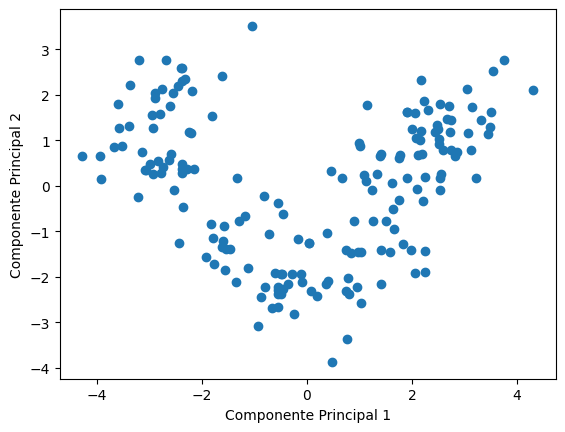

In [20]:
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

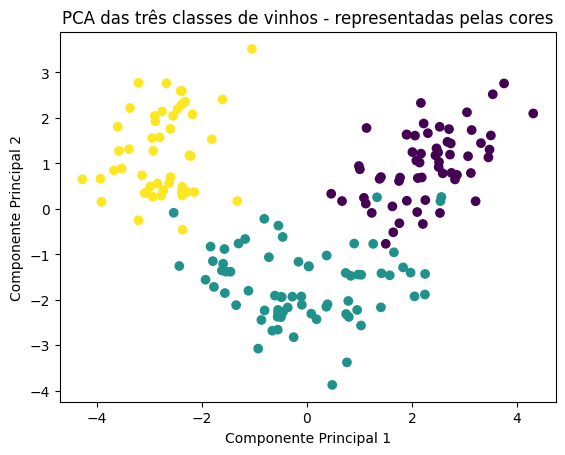

In [21]:
plt.title("PCA das três classes de vinhos - representadas pelas cores")
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['class'])
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

## __Referências:__
<font size=3>

- **(3.1 - 3.8)**: K. Faceli, Inteligência artificial: uma abordagem de aprendizado de máquina. Grupo Gen - LTC, 2011.
  